In [1]:
import os
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [2]:
import json

# Replace with your username and key
kaggle_json = {
    "username": "labidimahdi",
    "key": "KGAT_cd508928a093f9d98f6e6c791a532e15"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 88% 683M/778M [00:06<00:01, 56.8MB/s]
100% 778M/778M [00:06<00:00, 117MB/s] 


In [4]:
!unzip /content/covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [5]:
ORIGINAL_DATA_DIR = './COVID-19_Radiography_Dataset'
SPLIT_DATA_DIR = './COVID-19_Radiography_Splited_Dataset'

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [6]:
def create_dataset_splits(sourc_dir, train_dir, val_dir,test_dir, split_ratio=(0.7, 0.15, 0.15)):
    if not os.path.exists(sourc_dir):
        print(f"Error: could not find the source folder: {sourc_dir}")
        return
    classes = [d for d in os.listdir(sourc_dir) if os.path.isdir(os.path.join(sourc_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratio} (Train, Val, Test)...\n")
    for class_name in classes:
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        class_images_path = os.path.join(sourc_dir, class_name, 'images') # Point to the 'images' subfolder
        if not os.path.exists(class_images_path):
            print(f"Warning: images folder not found for class {class_name} at {class_images_path}. Skipping.")
            continue
        images = os.listdir(class_images_path)
        random.shuffle(images)

        total_images = len(images)
        if total_images == 0:
            print(f"Warning: No images found for class {class_name} in {class_images_path}. Skipping.")
            continue

        train_cut = int(total_images * split_ratio[0])
        val_cut = int(total_images * split_ratio[1])

        train_images = images[:train_cut]
        val_images = images[train_cut : train_cut + val_cut]
        test_images = images[train_cut + val_cut :]

        for img in train_images:
            shutil.copy(os.path.join(class_images_path, img), os.path.join(train_dir, class_name, img))
        for img in val_images:
            shutil.copy(os.path.join(class_images_path, img), os.path.join(val_dir, class_name, img))
        for img in test_images:
            shutil.copy(os.path.join(class_images_path, img), os.path.join(test_dir, class_name, img))

    print("Success! Images have been split into the robust 'data_split/' directory.")




create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 4 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

Success! Images have been split into the robust 'data_split/' directory.


In [7]:
def count_images(split_data_dir):
    for main_split in ['train', 'val', 'test']:
        split_path = os.path.join(split_data_dir, main_split)
        if not os.path.exists(split_path):
            os.makedirs(split_path)
            continue
        print(f"\n--- Output for {main_split.upper()} set ---")
        for disease_folder in os.listdir(split_path):
            disease_path = os.path.join(split_path, disease_folder)
            if os.path.isdir(disease_path):
                image_count = len(os.listdir(disease_path))
                print(f"  > {disease_folder}: {image_count} images")
count_images(SPLIT_DATA_DIR)


--- Output for TRAIN set ---
  > COVID: 2531 images
  > Lung_Opacity: 4208 images
  > Viral Pneumonia: 941 images
  > Normal: 7134 images

--- Output for VAL set ---
  > COVID: 542 images
  > Lung_Opacity: 901 images
  > Viral Pneumonia: 201 images
  > Normal: 1528 images

--- Output for TEST set ---
  > COVID: 543 images
  > Lung_Opacity: 903 images
  > Viral Pneumonia: 203 images
  > Normal: 1530 images


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    zoom_range=0.1
    )

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [9]:
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 14814 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Found 3179 images belonging to 4 classes.


In [10]:
from tensorflow.keras.regularizers import l2

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
EPOCHS = 30
MODEL_SAVE_PATH = './saved_model/covid19_densenet121.keras'

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 336s 631ms/step - accuracy: 0.5644 - loss: 1.2772 - val_accuracy: 0.8417 - val_loss: 0.4994 - learning_rate: 1.0000e-04
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 247s 533ms/step - accuracy: 0.8159 - loss: 0.5816 - val_accuracy: 0.8875 - val_loss: 0.3606 - learning_rate: 1.0000e-04
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 250s 539ms/step - accuracy: 0.8490 - loss: 0.4757 - val_accuracy: 0.8859 - val_loss: 0.3604 - learning_rate: 1.0000e-04
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 252s 544ms/step - accuracy: 0.8697 - loss: 0.4101 - val_accuracy: 0.9026 - val_loss: 0.3262 - learning_rate: 1.0000e-04
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 250s 540ms/step - accuracy: 0.8806 - loss: 0.3761 - val_accuracy: 0.9026 - val_loss: 0.3133 - learning_rate: 1.0000e-04
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 261s 563ms/step - accuracy: 0.8896 - loss: 0.3560 - val_accuracy: 0.9067 - val_loss: 0.2992 - learning_rate: 1.0000e-04
Epoch 7/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 

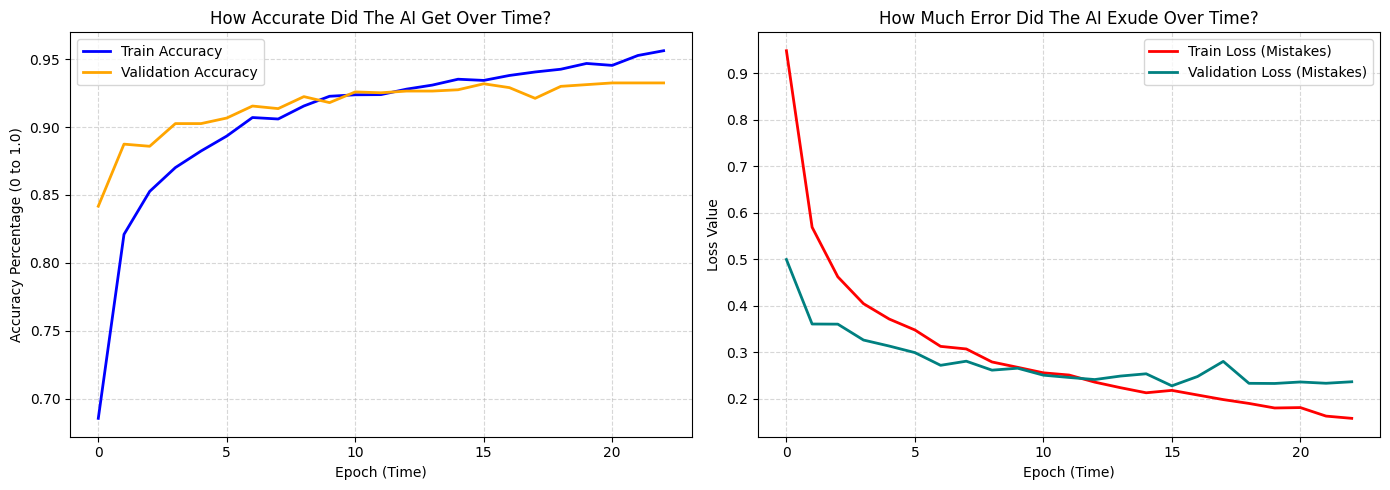

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 227ms/step - accuracy: 0.9057 - loss: 0.2749
🎯 Final Test Accuracy: 92.51%
📉 Final Test Loss/Error: 0.2152


100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 220ms/step
----------- PREDICTION TEXT REPORT -----------
                 precision    recall  f1-score   support

          COVID       0.98      0.90      0.94       543
   Lung_Opacity       0.92      0.87      0.89       903
         Normal       0.91      0.96      0.93      1530
Viral Pneumonia       0.98      0.94      0.96       203

       accuracy                           0.93      3179
      macro avg       0.94      0.92      0.93      3179
   weighted avg       0.93      0.93      0.92      3179



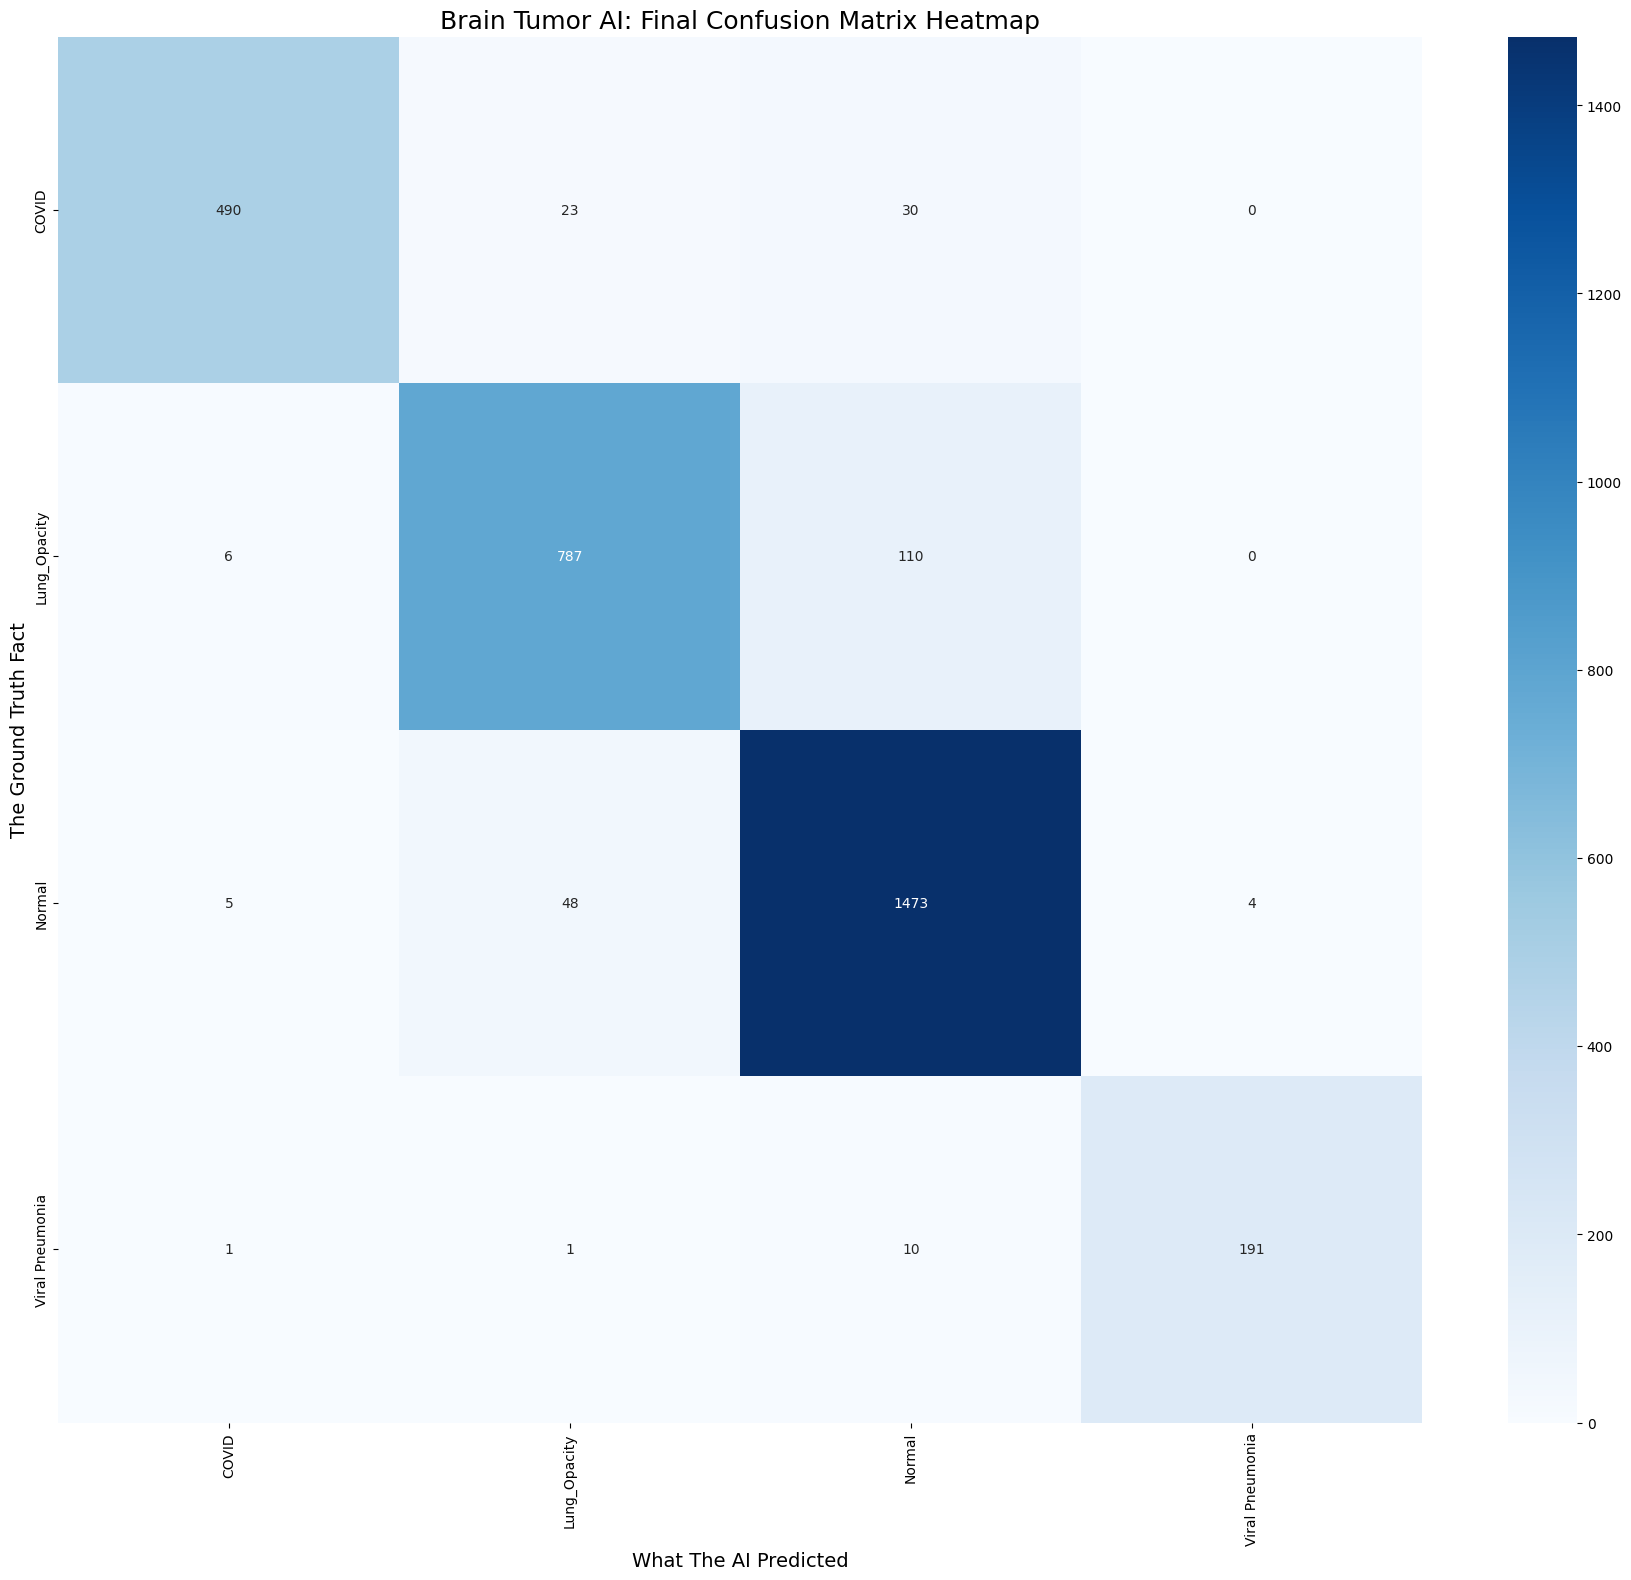

In [ ]:
test_generator.reset()

predictions_prob = model.predict(test_generator)

predicted_classes = np.argmax(predictions_prob, axis=1)

true_classes = test_generator.classes

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


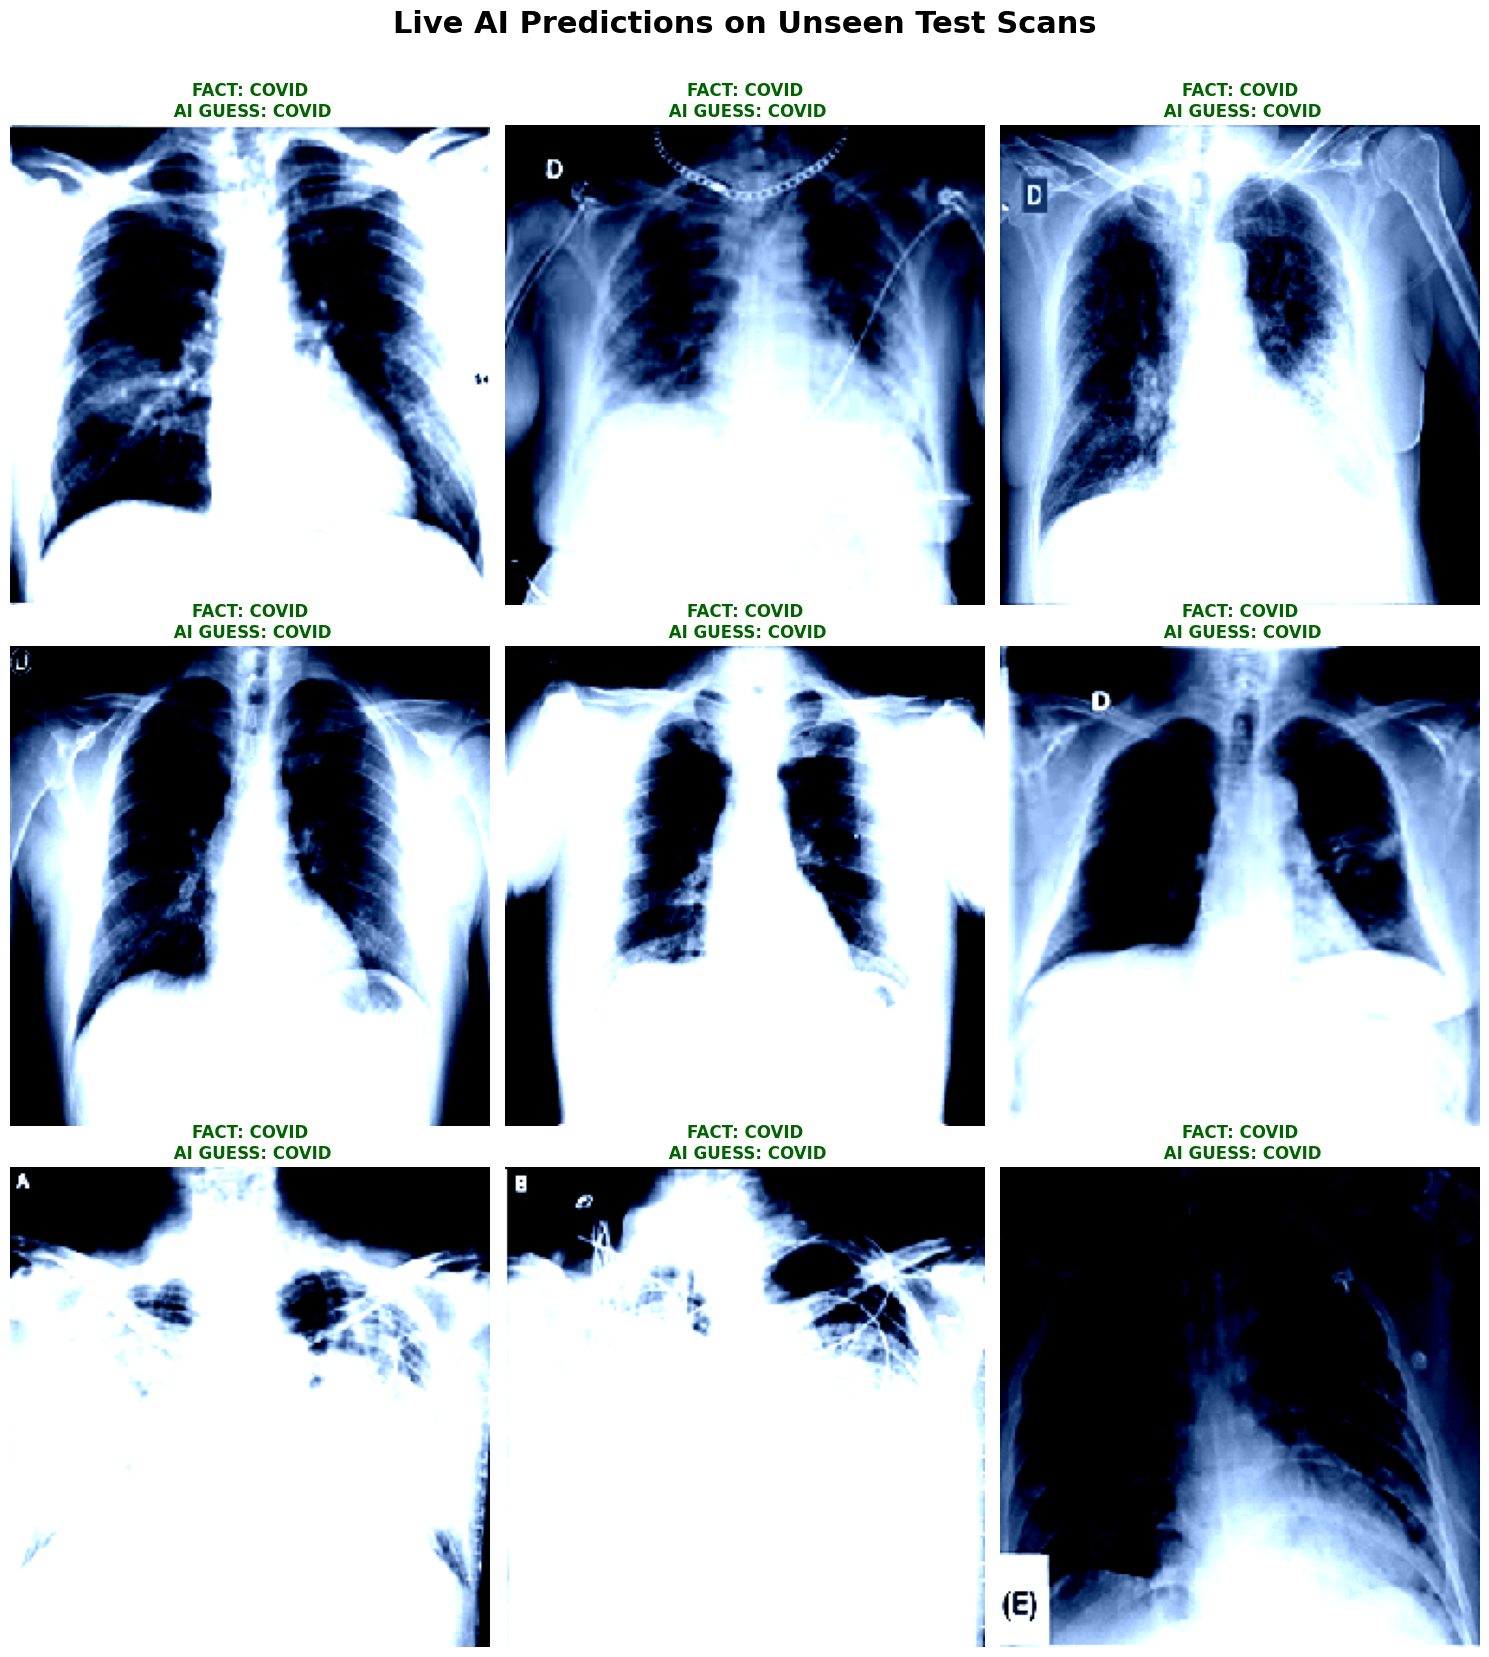

In [ ]:
test_generator.reset()
images, onehot_labels = next(test_generator)

preds = model.predict(images)

pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel()

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])

        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"

        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()